# Writing your own Neural Network code

In [18]:
import autograd.numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split

# custom imports
from source.runge_preprocessing import x, x_train, x_train_scaled, x_test, y, y_noise, y_train, y_test, ETA_VALUES, LAMBDA_VALUES
from source.neural_network import NN
import source.schedulers as schedulers
from source.cost_functions import mse
from source.utils import neural_network_loop, create_activations_layderdim
from source.plotting import plot_runges, plot_heatmap
import source.activation_functions as activations_functions



# OLS regression

### Results from project 1
Results from running code in project 1, jupyter file "assignment1_a_b.ipynb"

In section "Explore OLS in regards to polynomial degree, with noise" a small code were added to get smallest MSE Test value, and index for which polynomial degree.

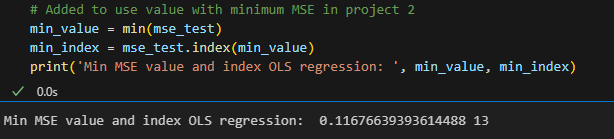

Hence, the best MSE on the test dataset was achieved when using polynomial degree 14.

# OLS with FFNN

From report 1 best results are acheived with learning rate 0.5 and 600 iterations. This can be seen in figure 8

# Own implementation of Neural Network


### Own implementation of FFNN

Hidden layers (50,100)

In [ ]:
# Settings for this task

ITERATIONS = 10
MOMENTUM = 0.9

VERBOSE = False
SHOW_PLOT = True
SAVE_FIGURE = True

OPTIMIZER = 'ADAM'
ACTIVATION_FUNC = 'sigmoid'

SAVE_FIGURE = True
SHOW_PLOT = True

RUNGE_HIDDEN = (50,100)



In [21]:
# Defining different activation functions and layers, and creating list and dimension to use in own FFNN code

# Activation output always linear with regression
ACTIVATION_FUNCTION_OUTPUT = activations_functions.linear
ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE = activations_functions.linear_derivative

if ACTIVATION_FUNC=='sigmoid':
    ACTIVATION_FUNCTION = activations_functions.sigmoid
    ACTIVATION_FUNCTION_DERIVATIVE = activations_functions.sigmoid_derivative
elif ACTIVATION_FUNC=='RELU':
    ACTIVATION_FUNCTION = activations_functions.RELU
    ACTIVATION_FUNCTION_DERIVATIVE = activations_functions.RELU_derivative
elif ACTIVATION_FUNC=='LRELU':
    ACTIVATION_FUNCTION = activations_functions.LRELU
    ACTIVATION_FUNCTION_DERIVATIVE = activations_functions.LRELU_derivative

activations, activations_derivative, _dim = create_activations_layderdim(ACTIVATION_FUNCTION, ACTIVATION_FUNCTION_DERIVATIVE, ACTIVATION_FUNCTION_OUTPUT, ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE, RUNGE_HIDDEN, y_train, x_train_scaled)



In [4]:
print(f'Dimensions of input, hidden, and output layer:\n{_dim}')

runge_NN = NN(_dim, activations, activations_derivative)

runge_results = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, OPTIMIZER, ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=MOMENTUM, verbose=True)


Dimensions of input, hidden, and output layer:
[1, 50, 100, 1]

Training with: optimizer=ADAM, lr=0.1, lambda=0.01, iteration=10
Using scheduler: ADAM with Eta=0.1

Training with: optimizer=ADAM, lr=0.1, lambda=0.005994842503189409, iteration=10
Using scheduler: ADAM with Eta=0.1

Training with: optimizer=ADAM, lr=0.1, lambda=0.003593813663804626, iteration=10
Using scheduler: ADAM with Eta=0.1

Training with: optimizer=ADAM, lr=0.1, lambda=0.0021544346900318843, iteration=10
Using scheduler: ADAM with Eta=0.1

Training with: optimizer=ADAM, lr=0.1, lambda=0.001291549665014884, iteration=10
Using scheduler: ADAM with Eta=0.1

Training with: optimizer=ADAM, lr=0.1, lambda=0.000774263682681127, iteration=10
Using scheduler: ADAM with Eta=0.1

Training with: optimizer=ADAM, lr=0.1, lambda=0.0004641588833612782, iteration=10
Using scheduler: ADAM with Eta=0.1

Training with: optimizer=ADAM, lr=0.1, lambda=0.0002782559402207126, iteration=10
Using scheduler: ADAM with Eta=0.1

Training with

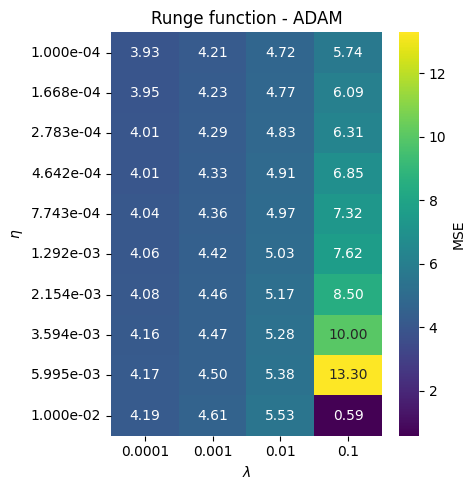

Learning Rate                                                      0.1
Lambda                                                            0.01
Iterations                                                          10
Elapsed Time (s)                                                  0.12
Training Errors      [508.6419901085741, 3.3432336575331307, 491.95...
Validation Errors    [517.7508377858842, 3.4127694091856258, 505.13...
MSE                                                           0.588878
Predictions          [[-0.6377578686358092], [0.16455487864364038],...
Name: 0, dtype: object


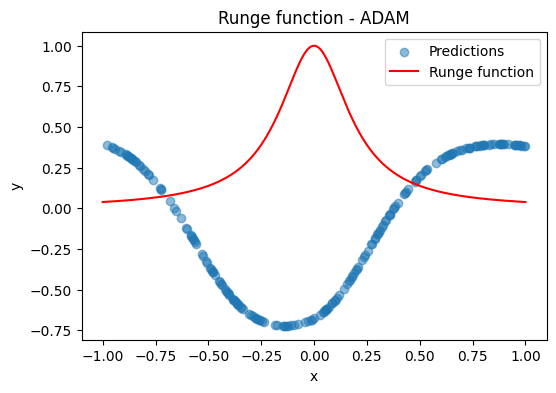

In [ ]:
# Plotting

plot_heatmap(runge_results, title=f'Runge function - {OPTIMIZER}', heat_metric='MSE', filename=f'part_b-heatmap_{RUNGE_HIDDEN}_{OPTIMIZER}_afunc{ACTIVATION_FUNC}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# Print best MSE 
min_row = runge_results.loc[runge_results['MSE'].idxmin()]
predictions = runge_results.loc[runge_results['MSE'].idxmin(), 'Predictions']
plot_runges(x, y, x_test, predictions, title=f'Runge function - {OPTIMIZER}',filename=f'part_b-heatmap_{RUNGE_HIDDEN}_{OPTIMIZER}_afunc{ACTIVATION_FUNC}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)